# Roteiro de Laboratório 2 — Identificação de sistemas representados por equações a diferenças

**Disciplina:** ECOM-121 — Introdução à identificação de sistemas (UFAL, 2026.1)

Este notebook implementa as seis questões do roteiro:

1. **Questão 1** — análise dos sistemas $G_a(s)$ e $G_b(s)$: degrau, polos, discretização ZOH ($T_s = 0{,}1$ s), equação às diferenças e comparação contínuo/discreto.
2. **Questão 2** — simulação via equação a diferença (degrau e entrada uniforme), EMQ de ordens 1 a 5 e Monte Carlo com ruído dinâmico e de sensor.
3. **Questão 3** — validação dos modelos identificados na Questão 2 via erro quadrático, coeficiente de correlação múltipla ($R^2$) e razão sinal-ruído (SNR).
4. **Questão 4** — identificação dos datasets **1 e 2** com modelos ARX e ARMAX de ordem 1 a 5, tabelando o MSE de estimação e validação.
5. **Questão 5** — identificação dos datasets **3 e 4**, com verificação de variação temporal dos parâmetros via mínimos quadrados recursivo.
6. **Questão 6** — identificação dos datasets **5 e 6** usando os critérios de Akaike e Bayes para escolha de estrutura, combinados com mínimos quadrados recursivo estendido (RELS) para modelos ARMAX.

Todo o código usa apenas `numpy`, `matplotlib` e `python-control`.


## Bibliotecas e utilitários comuns

Centraliza os imports e define funções que serão reutilizadas ao longo do notebook:

- `simulate_diffeq` — resolve a equação a diferença `den*y = num*u` iterativamente (condições iniciais nulas).
- `build_regressor_arx` / `lse_fit_arx` — montam o regressor ARX e aplicam mínimos quadrados padrão.
- `armax_fit` — ARMAX por mínimos quadrados estendidos iterativos (atualiza a estimativa do ruído a cada passada).
- `rls_arx` / `rels_armax` — versões recursivas.
- Métricas: SSE, $R^2$ e SNR.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 90


def simulate_diffeq(num, den, u):
    """Simula y[k] pela equação às diferenças:
        den[0]*y[k] + sum_i>=1 den[i]*y[k-i] = sum_j num[j]*u[k-1-j]
    com y[k<0] = u[k<0] = 0 (repouso)."""
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    N = len(u)
    y = np.zeros(N)
    nb = len(num)
    na = len(den) - 1
    for k in range(N):
        acc = 0.0
        for j in range(nb):
            idx = k - (j + 1)
            if idx >= 0:
                acc += num[j] * u[idx]
        for i in range(1, na + 1):
            idx = k - i
            if idx >= 0:
                acc -= den[i] * y[idx]
        y[k] = acc / den[0]
    return y


def build_regressor_arx(y, u, n):
    """Phi (N-n, 2n): [y[k-1],...,y[k-n], u[k-1],...,u[k-n]]."""
    N = len(y)
    Phi = np.zeros((N - n, 2 * n))
    Y = np.zeros(N - n)
    for k in range(n, N):
        row = [y[k - i] for i in range(1, n + 1)] + [u[k - j] for j in range(1, n + 1)]
        Phi[k - n] = row
        Y[k - n] = y[k]
    return Phi, Y


def lse_fit_arx(y, u, n):
    """Mínimos Quadrados ARX. Retorna theta, resíduo e y_hat."""
    Phi, Y = build_regressor_arx(y, u, n)
    theta, *_ = np.linalg.lstsq(Phi, Y, rcond=None)
    y_hat = Phi @ theta
    return theta, Y - y_hat, y_hat


def armax_fit(y, u, n, max_iter=20, tol=1e-8):
    """ARMAX via Mínimos Quadrados Estendidos iterativo.
    Regressor: [y[k-1..k-n], u[k-1..k-n], e[k-1..k-n]]. O ruído e[k] é
    inicializado com zeros e, a cada iteração, substituído pelo resíduo atual."""
    N = len(y)
    e_hat = np.zeros(N)
    theta_prev = np.zeros(3 * n)
    for _ in range(max_iter):
        Phi = np.zeros((N - n, 3 * n))
        Y = np.zeros(N - n)
        for k in range(n, N):
            row = (
                [y[k - i] for i in range(1, n + 1)]
                + [u[k - j] for j in range(1, n + 1)]
                + [e_hat[k - m] for m in range(1, n + 1)]
            )
            Phi[k - n] = row
            Y[k - n] = y[k]
        theta, *_ = np.linalg.lstsq(Phi, Y, rcond=None)
        y_hat = Phi @ theta
        res = Y - y_hat
        e_hat[n:] = res
        if np.linalg.norm(theta - theta_prev) < tol:
            break
        theta_prev = theta
    return theta, res, y_hat


def predict_arx(theta, y, u, n):
    """Predição de um passo a frente usando modelo ARX(n) já identificado."""
    N = len(y)
    a = theta[:n]
    b = theta[n:]
    y_hat = np.zeros(N)
    for k in range(n, N):
        y_hat[k] = sum(a[i - 1] * y[k - i] for i in range(1, n + 1)) + sum(
            b[j - 1] * u[k - j] for j in range(1, n + 1)
        )
    return y_hat


def predict_armax(theta, y, u, n):
    """Predição ARMAX(n) um passo à frente. e[k] é aproximado pelo resíduo."""
    N = len(y)
    a = theta[:n]
    b = theta[n : 2 * n]
    c = theta[2 * n :]
    y_hat = np.zeros(N)
    e_hat = np.zeros(N)
    for k in range(n, N):
        y_hat[k] = (
            sum(a[i - 1] * y[k - i] for i in range(1, n + 1))
            + sum(b[j - 1] * u[k - j] for j in range(1, n + 1))
            + sum(c[m - 1] * e_hat[k - m] for m in range(1, n + 1))
        )
        e_hat[k] = y[k] - y_hat[k]
    return y_hat


def rls_arx(y, u, n, lam=1.0, P0=1000.0):
    """Mínimos Quadrados Recursivo para ARX(n).
    Retorna theta final, histórico de theta e vetor de erros de predição."""
    N = len(y)
    theta = np.zeros(2 * n)
    P = P0 * np.eye(2 * n)
    theta_hist = np.zeros((N, 2 * n))
    err_hist = np.zeros(N)
    for k in range(n, N):
        phi = np.concatenate(
            [[y[k - i] for i in range(1, n + 1)], [u[k - j] for j in range(1, n + 1)]]
        )
        denom = lam + phi @ P @ phi
        K = (P @ phi) / denom
        err = y[k] - phi @ theta
        theta = theta + K * err
        P = (P - np.outer(K, phi) @ P) / lam
        theta_hist[k] = theta
        err_hist[k] = err
    return theta, theta_hist, err_hist


def rels_armax(y, u, n, lam=1.0, P0=1000.0):
    """Mínimos Quadrados Recursivo Estendido para ARMAX(n).
    Regressor inclui estimativas passadas do ruído (resíduos)."""
    N = len(y)
    theta = np.zeros(3 * n)
    P = P0 * np.eye(3 * n)
    theta_hist = np.zeros((N, 3 * n))
    e_hat = np.zeros(N)
    for k in range(n, N):
        phi = np.concatenate(
            [
                [y[k - i] for i in range(1, n + 1)],
                [u[k - j] for j in range(1, n + 1)],
                [e_hat[k - m] for m in range(1, n + 1)],
            ]
        )
        denom = lam + phi @ P @ phi
        K = (P @ phi) / denom
        err = y[k] - phi @ theta
        theta = theta + K * err
        P = (P - np.outer(K, phi) @ P) / lam
        theta_hist[k] = theta
        e_hat[k] = err
    return theta, theta_hist, e_hat


def metrics(y_true, y_pred, valid_start=0):
    """Calcula SSE, MSE, R² e SNR (dB) ignorando os primeiros valid_start pontos."""
    yt = y_true[valid_start:]
    yp = y_pred[valid_start:]
    res = yt - yp
    sse = float(np.sum(res ** 2))
    mse = sse / len(yt)
    sst = float(np.sum((yt - yt.mean()) ** 2))
    r2 = 1.0 - sse / sst if sst > 0 else float("nan")
    var_res = np.var(res)
    snr_db = 10.0 * np.log10(np.var(yt) / var_res) if var_res > 0 else float("inf")
    return dict(SSE=sse, MSE=mse, R2=r2, SNR_dB=snr_db)


def aic_bic(sse, N, p):
    """Critérios de informação de Akaike (AIC) e Bayes (BIC).
    AIC = N ln(SSE/N) + 2p ; BIC = N ln(SSE/N) + p ln(N)."""
    sigma2 = sse / N
    return dict(AIC=N * np.log(sigma2) + 2 * p, BIC=N * np.log(sigma2) + p * np.log(N))


## Questão 1 — Sistemas contínuos, polos, ZOH e equação às diferenças

Sistemas em malha aberta:

$$G_a(s) = \frac{0{,}5 s^{2} + 2s + 2}{s^{3} + 3s^{2} + 4s + 2}
\qquad
G_b(s) = \frac{2{,}5}{s^{2} + s + 2{,}5}$$

Passos do enunciado:

1. Resposta ao **degrau unitário** de cada um (contínuo).
2. **Análise dos polos** ($\zeta$, $\omega_n$, estabilidade, ganho DC).
3. **Discretização ZOH** com $T_s = 0{,}1$ s.
4. **Equação às diferenças explícita** de cada $G(z)$.
5. **Comparação** entre a resposta contínua ao degrau e a simulação discreta ZOH.


Polos e ganho DC

G_a: polos = [-1.+1.j -1.-1.j -1.+0.j], G(0) = 1.0000
G_b: polos = [-0.5+1.5j -0.5-1.5j], G(0) = 1.0000
  valor final ~ 1.0000 (para $G_a(s)$)
  valor final ~ 0.9985 (para $G_b(s)$)


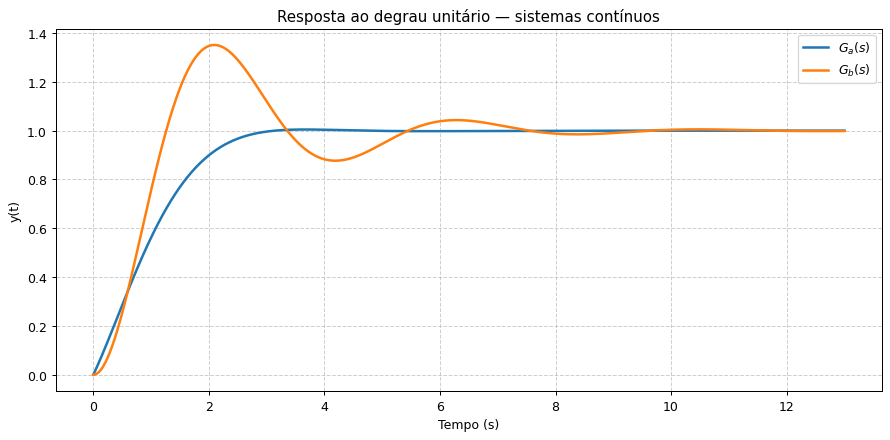

In [8]:
s = ct.tf("s")

ga = (0.5 * s ** 2 + 2 * s + 2) / (s ** 3 + 3 * s ** 2 + 4 * s + 2)
gb = 2.5 / (s ** 2 + s + 2.5)

systems = [ga, gb]
labels = [r"$G_a(s)$", r"$G_b(s)$"]

print("Polos e ganho DC\n")
for sys, name in zip(systems, ["G_a", "G_b"]):
    p = ct.poles(sys)
    print(f"{name}: polos = {p}, G(0) = {ct.dcgain(sys):.4f}")

# Resposta ao degrau unitário
fig, ax = plt.subplots(figsize=(10, 5))
T_common = np.linspace(0, 13.0, 2000) 
for sys, label in zip(systems, labels):
    t, y = ct.step_response(sys, T=T_common)
    ax.plot(t, y, label=label, linewidth=2)
    print(f"  valor final ~ {y[-1]:.4f} (para {label})")
ax.set_xlabel("Tempo (s)"); ax.set_ylabel("y(t)")
ax.set_title("Resposta ao degrau unitário — sistemas contínuos")
ax.grid(True, linestyle="--", alpha=0.6); ax.legend()
fig.tight_layout(); plt.show()


### 1.2 Análise em função dos polos

**$G_a(s)$.** O denominador fatora como $(s+1)(s^2+2s+2)$. Polos em $s = -1$ (real) e $s = -1 \pm j$ (par complexo). Todos no semiplano esquerdo → **BIBO estável**. O numerador é $0{,}5(s+2)^2$, logo dois zeros em $s = -2$. Ganho DC $G_a(0) = 1$. O par complexo corresponde a $\omega_n = \sqrt{2}$ rad/s e $\zeta = 1/\sqrt{2} \approx 0{,}707$ — **subamortecido moderado**. Os zeros à esquerda dos polos tendem a **reduzir o sobressinal**.

**$G_b(s)$.** Segunda ordem, polos $s = -0{,}5 \pm j\,\sqrt{2{,}25}$. Forma padrão: $\omega_n = \sqrt{2{,}5}$ rad/s e $\zeta = 0{,}5/\sqrt{2{,}5} \approx 0{,}316$ — **subamortecido mais fraco** que $G_a$, logo maior sobressinal. Sem zeros finitos. Ganho DC $G_b(0) = 1{,}0$.

**Comparando.** Ambos estáveis, mas $G_b$ tem polos **mais próximos do eixo imaginário** (parte real $-0{,}5$ vs $-1$), levando a uma envoltória que decai mais lentamente e oscilação mais visível na resposta ao degrau.


In [ ]:
Ts = 0.1
ga_d = ct.c2d(ga, Ts, method="zoh")
gb_d = ct.c2d(gb, Ts, method="zoh")

print(f"Discretização ZOH, Ts = {Ts} s\n")
print("G_a(z) =\n", ga_d)
print("\nG_b(z) =\n", gb_d)


def poly_str(coeffs, var="z"):
    c = np.asarray(coeffs, dtype=float)
    deg = len(c) - 1
    parts = []
    for i, ak in enumerate(c):
        if abs(ak) < 1e-12:
            continue
        p = deg - i
        if p == 0:
            term = f"{ak:+.6g}"
        elif p == 1:
            term = f"{ak:+.6g} {var}"
        else:
            term = f"{ak:+.6g} {var}^{p}"
        parts.append(term)
    return " ".join(parts) if parts else "0"


def explicit_diffeq(label, sys_d):
    num = np.array(sys_d.num[0][0], dtype=float)
    den = np.array(sys_d.den[0][0], dtype=float)
    print(f"\n--- {label} ---")
    print(f"  {label}(z) = ({poly_str(num)}) / ({poly_str(den)})")

    lhs = f"{den[0]:+.6g} y[k]"
    for i in range(1, len(den)):
        lhs += f" {'+' if den[i] >= 0 else '-'} {abs(den[i]):.6g} y[k-{i}]"
    rhs = f"{num[0]:+.6g} u[k-1]"
    for j in range(1, len(num)):
        rhs += f" {'+' if num[j] >= 0 else '-'} {abs(num[j]):.6g} u[k-{j + 1}]"
    print(f"  equação às diferenças:  {lhs} = {rhs}")
    return num, den


num_a, den_a = explicit_diffeq("G_a", ga_d)
num_b, den_b = explicit_diffeq("G_b", gb_d)


Discretização ZOH, Ts = 0.1 s

G_a(z) =
 <TransferFunction>: sys[25]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

    0.0523 z^2 - 0.0855 z + 0.035
  ----------------------------------
  z^3 - 2.705 z^2 + 2.448 z - 0.7408

G_b(z) =
 <TransferFunction>: sys[33]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

    0.0121 z + 0.0117
  ----------------------
  z^2 - 1.881 z + 0.9048

--- G_a ---
  G_a(z) = (+0.0522563 z^2 -0.0855332 z +0.0349991) / (+1 z^3 -2.70547 z^2 +2.44801 z -0.740818)
  equação às diferenças:  +1 y[k] - 2.70547 y[k-1] + 2.44801 y[k-2] - 0.740818 y[k-3] = +0.0522563 u[k-1] - 0.0855332 u[k-2] + 0.0349991 u[k-3]

--- G_b ---
  G_b(z) = (+0.0120685 z +0.0116726) / (+1 z^2 -1.8811 z +0.904837)
  equação às diferenças:  +1 y[k] - 1.8811 y[k-1] + 0.904837 y[k-2] = +0.0120685 u[k-1] + 0.0116726 u[k-2]


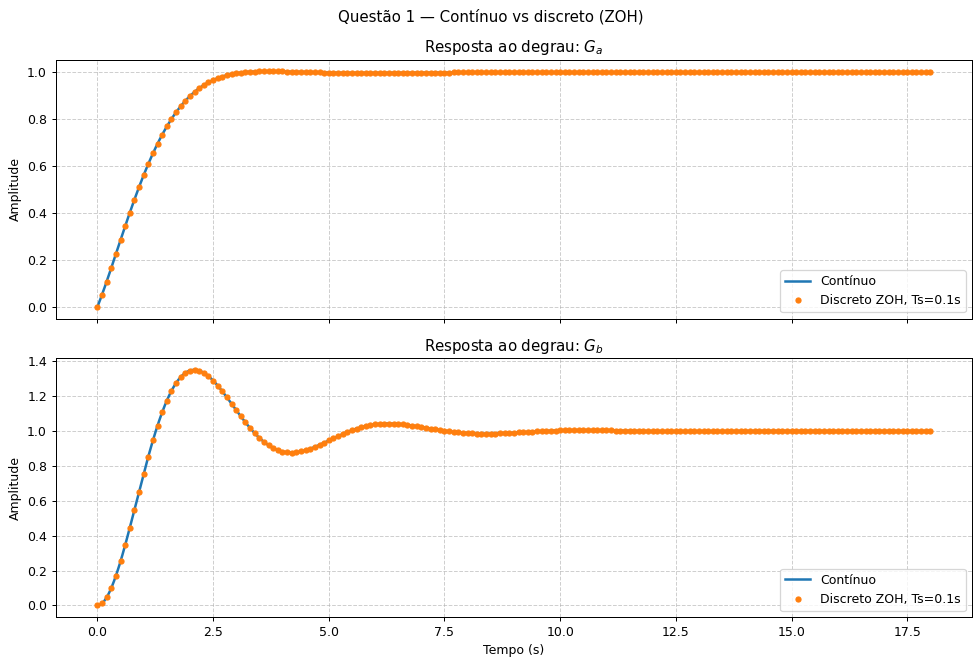

In [ ]:
# Comparação: degrau contínuo vs degrau discreto (ZOH)
t_end = 18.0
t_cont = np.linspace(0.0, t_end, 2000)
t_disc = np.arange(0.0, t_end + Ts / 2, Ts)

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for ax, (sys_c, sys_d, name) in zip(
    axes, [(ga, ga_d, r"$G_a$"), (gb, gb_d, r"$G_b$")]
):
    tc, yc = ct.step_response(sys_c, T=t_cont)
    td, yd = ct.step_response(sys_d, T=t_disc)
    ax.plot(tc, yc, "-", linewidth=2, label="Contínuo")
    ax.plot(td, yd, "o", markersize=4, label=f"Discreto ZOH, Ts={Ts}s")
    ax.set_title(f"Resposta ao degrau: {name}")
    ax.set_ylabel("Amplitude")
    ax.grid(True, linestyle="--", alpha=0.6); ax.legend(loc="lower right")
axes[-1].set_xlabel("Tempo (s)")
fig.suptitle("Questão 1 — Contínuo vs discreto (ZOH)")
fig.tight_layout(); plt.show()


A sobreposição dos pontos discretos sobre a curva contínua mostra que, com $T_s = 0{,}1$ s, o equivalente ZOH **preserva fielmente** a dinâmica dos dois sistemas. Para $T_s$ maior, essa aderência se deterioraria (aliasing / perda de informação entre amostras).


## Questão 2 — Simulação, EMQ ordem 1 a 5 e Monte Carlo

### 2.1 Simulação via equação a diferença (100 amostras, sem ruído)

Duas entradas distintas:

- **Degrau unitário** ($u[k] = 1$): útil para verificar o ganho DC e a forma do transitório.
- **Uniforme em $[-1, 1]$**: distribui energia em toda a banda — é uma entrada **persistentemente excitante**, necessária para identificar modelos de ordem > 1.

A saída é gerada pela função `simulate_diffeq` aplicada aos coeficientes $num$/$den$ obtidos na Questão 1.


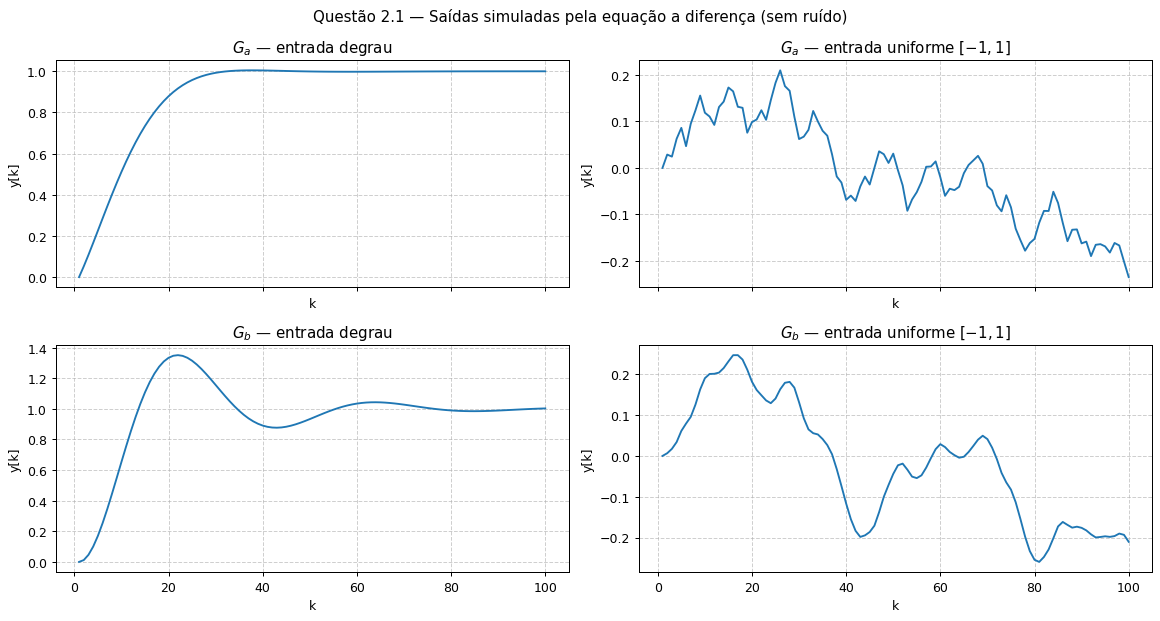

In [ ]:
N = 100
rng_in = np.random.default_rng(seed=42)

u_step = np.ones(N)
u_unif = rng_in.uniform(-1.0, 1.0, size=N)

y_a_step = simulate_diffeq(num_a, den_a, u_step)
y_a_unif = simulate_diffeq(num_a, den_a, u_unif)
y_b_step = simulate_diffeq(num_b, den_b, u_step)
y_b_unif = simulate_diffeq(num_b, den_b, u_unif)

k_axis = np.arange(1, N + 1)
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
axes[0, 0].plot(k_axis, y_a_step); axes[0, 0].set_title(r"$G_a$ — entrada degrau")
axes[0, 1].plot(k_axis, y_a_unif); axes[0, 1].set_title(r"$G_a$ — entrada uniforme $[-1,1]$")
axes[1, 0].plot(k_axis, y_b_step); axes[1, 0].set_title(r"$G_b$ — entrada degrau")
axes[1, 1].plot(k_axis, y_b_unif); axes[1, 1].set_title(r"$G_b$ — entrada uniforme $[-1,1]$")
for ax in axes.ravel():
    ax.set_xlabel("k"); ax.set_ylabel("y[k]"); ax.grid(True, ls="--", alpha=0.6)
fig.suptitle("Questão 2.1 — Saídas simuladas pela equação a diferença (sem ruído)")
fig.tight_layout(); plt.show()


### 2.2 EMQ de ordens 1 a 5 — resíduos e análise

Modelo ARX de ordem $n$:
$$y[k] = \sum_{i=1}^{n} a_i\, y[k-i] + \sum_{j=1}^{n} b_j\, u[k-j] + e[k].$$

A identificação é feita sobre a saída `y_a_unif` (entrada persistente): sem ela, a matriz $\Phi^T\Phi$ fica mal-condicionada para ordens altas.

Espera-se que o **RMS do resíduo** despenque quando $n$ alcança a ordem real (3, pois $G_a$ é de 3ª ordem) e estagne depois.


 ordem     media resíduo     RMS resíduo    # parâmetros
     1       -7.0354e-04      4.5703e-03               2
     2        1.6064e-05      4.9306e-05               4
     3       -1.6990e-18      2.7312e-16               6
     4       -2.1792e-17      2.7281e-16               8
     5        4.2181e-18      2.0830e-16              10


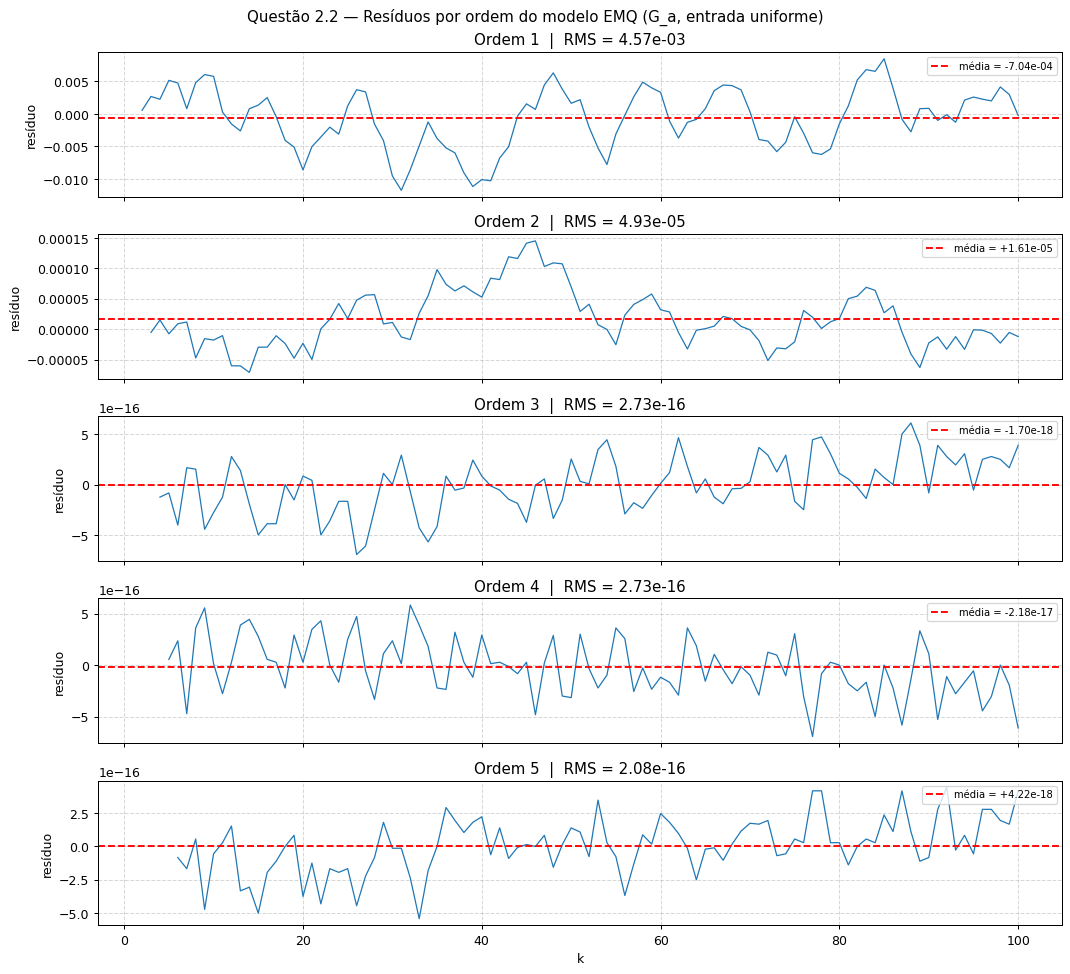

In [ ]:
y_id = y_a_unif
u_id = u_unif
ordens = range(1, 6)

fig, axes = plt.subplots(len(ordens), 1, figsize=(12, 11), sharex=True)
thetas_by_order = {}

print(f"{'ordem':>6}{'media resíduo':>18}{'RMS resíduo':>16}{'# parâmetros':>16}")
for ax, n in zip(axes, ordens):
    theta, res, _ = lse_fit_arx(y_id, u_id, n)
    thetas_by_order[n] = theta
    media = float(res.mean()); rms = float(np.sqrt((res ** 2).mean()))
    k_res = np.arange(n + 1, N + 1)
    ax.plot(k_res, res, linewidth=1)
    ax.axhline(media, color="red", linestyle="--", label=f"média = {media:+.2e}")
    ax.set_title(f"Ordem {n}  |  RMS = {rms:.2e}")
    ax.set_ylabel("resíduo"); ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, ls="--", alpha=0.5)
    print(f"{n:>6d}{media:>18.4e}{rms:>16.4e}{2 * n:>16d}")
axes[-1].set_xlabel("k")
fig.suptitle("Questão 2.2 — Resíduos por ordem do modelo EMQ (G_a, entrada uniforme)")
fig.tight_layout(); plt.show()


**Leitura do resultado.** Para $n \in \{1, 2\}$ o resíduo exibe estrutura oscilatória — o modelo é **simples demais**. Para $n = 3$ (ordem real) o RMS cai a nível numérico ($\sim 10^{-16}$) e o resíduo vira ruído numérico. Para $n \in \{4, 5\}$ o RMS não melhora: os parâmetros extras ficam mal-determinados. Portanto a ordem correta — no caso sem ruído — é exatamente 3.

### 2.3 Monte Carlo com ruído (100 realizações, ordem 3)

Duas configurações:

- **Ruído dinâmico:** $e[k] \sim \mathcal{N}(0, \sigma^2)$ é somado a $y[k]$ **dentro** da recursão, de modo que realimenta o sistema no próximo passo.
- **Ruído de sensor:** adicionado de uma vez à saída limpa já simulada, sem realimentação.

A distinção é crucial: no caso dinâmico o EMQ é **consistente** (média converge para o verdadeiro); no caso de sensor há **errors-in-variables** porque os regressores $y[k-i]$ passam a carregar ruído, produzindo **viés**.


Monte Carlo — N_MC = 100, sigma = 0.05, n = 3

param     verdadeiro     média dyn    desvio dyn    média sensor   desvio sensor
$a_1$       2.705471      2.662165      0.086356        0.320958        0.099932
$a_2$      -2.448012     -2.365968      0.172994        0.269455        0.104836
$a_3$       0.740818      0.701391      0.088212        0.288071        0.082681
$b_1$       0.052256      0.053907      0.009365        0.050902        0.009960
$b_2$      -0.085533     -0.083036      0.010208        0.042368        0.011984
$b_3$       0.034999      0.033350      0.010442        0.028564        0.011366


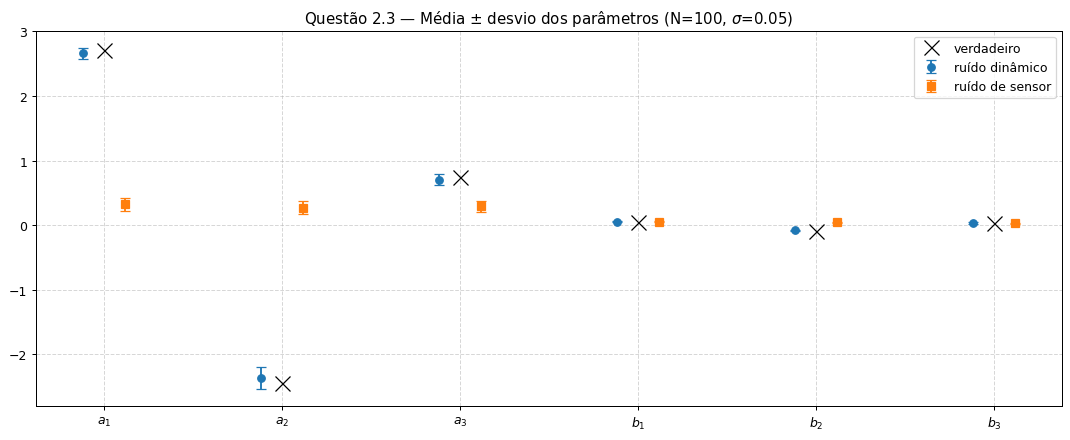

In [ ]:
def simulate_with_dynamic_noise(num, den, u, sigma, rng):
    N = len(u)
    y = np.zeros(N)
    nb = len(num); na = len(den) - 1
    e = rng.normal(0.0, sigma, size=N)
    for k in range(N):
        acc = 0.0
        for j in range(nb):
            idx = k - (j + 1)
            if idx >= 0:
                acc += num[j] * u[idx]
        for i in range(1, na + 1):
            idx = k - i
            if idx >= 0:
                acc -= den[i] * y[idx]
        y[k] = acc / den[0] + e[k]
    return y


sigma = 0.05
N_MC = 100
n_model = 3

rng_mc = np.random.default_rng(seed=123)
u_mc = rng_mc.uniform(-1.0, 1.0, size=N)
y_limpo = simulate_diffeq(num_a, den_a, u_mc)

thetas_dyn = np.zeros((N_MC, 2 * n_model))
thetas_sen = np.zeros((N_MC, 2 * n_model))
for i in range(N_MC):
    rng_i = np.random.default_rng(seed=1000 + i)
    y_dyn = simulate_with_dynamic_noise(num_a, den_a, u_mc, sigma, rng_i)
    thetas_dyn[i], *_ = lse_fit_arx(y_dyn, u_mc, n_model)
    E = rng_i.normal(0.0, sigma, size=N)
    thetas_sen[i], *_ = lse_fit_arx(y_limpo + E, u_mc, n_model)

theta_true = np.concatenate([-den_a[1:], num_a])
nomes = [r"$a_1$", r"$a_2$", r"$a_3$", r"$b_1$", r"$b_2$", r"$b_3$"]

print(f"Monte Carlo — N_MC = {N_MC}, sigma = {sigma}, n = {n_model}\n")
print(f"{'param':<6}{'verdadeiro':>14}{'média dyn':>14}{'desvio dyn':>14}"
      f"{'média sensor':>16}{'desvio sensor':>16}")
for j in range(2 * n_model):
    print(f"{nomes[j]:<6}{theta_true[j]:>14.6f}"
          f"{thetas_dyn[:, j].mean():>14.6f}{thetas_dyn[:, j].std():>14.6f}"
          f"{thetas_sen[:, j].mean():>16.6f}{thetas_sen[:, j].std():>16.6f}")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(2 * n_model)
ax.errorbar(x - 0.12, thetas_dyn.mean(0), yerr=thetas_dyn.std(0), fmt="o",
            capsize=4, label="ruído dinâmico")
ax.errorbar(x + 0.12, thetas_sen.mean(0), yerr=thetas_sen.std(0), fmt="s",
            capsize=4, label="ruído de sensor")
ax.plot(x, theta_true, "kx", markersize=12, label="verdadeiro")
ax.set_xticks(x); ax.set_xticklabels(nomes)
ax.set_title(fr"Questão 2.3 — Média $\pm$ desvio dos parâmetros (N={N_MC}, $\sigma$={sigma})")
ax.legend(); ax.grid(True, ls="--", alpha=0.5)
fig.tight_layout(); plt.show()


**Interpretação.** Observa-se que o **ruído dinâmico** deixa a média dos parâmetros **próxima do valor verdadeiro** (viés desprezível), enquanto o **ruído de sensor** introduz **viés significativo** — consequência do fenômeno *errors-in-variables*, em que os regressores $y[k-i]$ estão contaminados por ruído.

Em aplicações reais onde predomina ruído de sensor usa-se EMQE (estendido), **variáveis instrumentais** ou a estrutura **Output-Error**.


## Questão 3 — Validação dos modelos identificados

**Ideia-chave.** Um bom modelo precisa generalizar: ele foi ajustado em um conjunto de dados e deve ser testado em **outro** conjunto, não visto durante a estimação. Os três indicadores do enunciado:

- **Somatório do erro quadrático (SSE)** e seu equivalente médio (MSE) sobre os dados de validação.
- **Coeficiente de correlação múltipla** $R^2 = 1 - \dfrac{\mathrm{SSE}}{\mathrm{SST}}$, onde $\mathrm{SST} = \sum (y - \bar y)^2$. Valor próximo de 1 ⇒ o modelo explica quase toda a variância.
- **Razão sinal-ruído (SNR)** em dB: $\mathrm{SNR} = 10\log_{10}\!\left(\dfrac{\mathrm{var}(y)}{\mathrm{var}(y - \hat y)}\right)$.

Usamos os modelos ARX de ordem 1–5 ajustados na Questão 2 (em `thetas_by_order`) e os validamos em uma **nova realização** da entrada uniforme — mesma natureza do sinal de estimação, mas sementes diferentes.


 ordem           SSE           MSE          R²    SNR (dB)
     1    7.3535e-03    7.4278e-05    0.997042       25.34
     2    1.2266e-06    1.2516e-08    1.000000       63.14
     3    1.0057e-29    1.0368e-31    1.000000      294.72
     4    1.1776e-29    1.2267e-31    1.000000      293.54
     5    8.6983e-30    9.1561e-32    1.000000      295.02


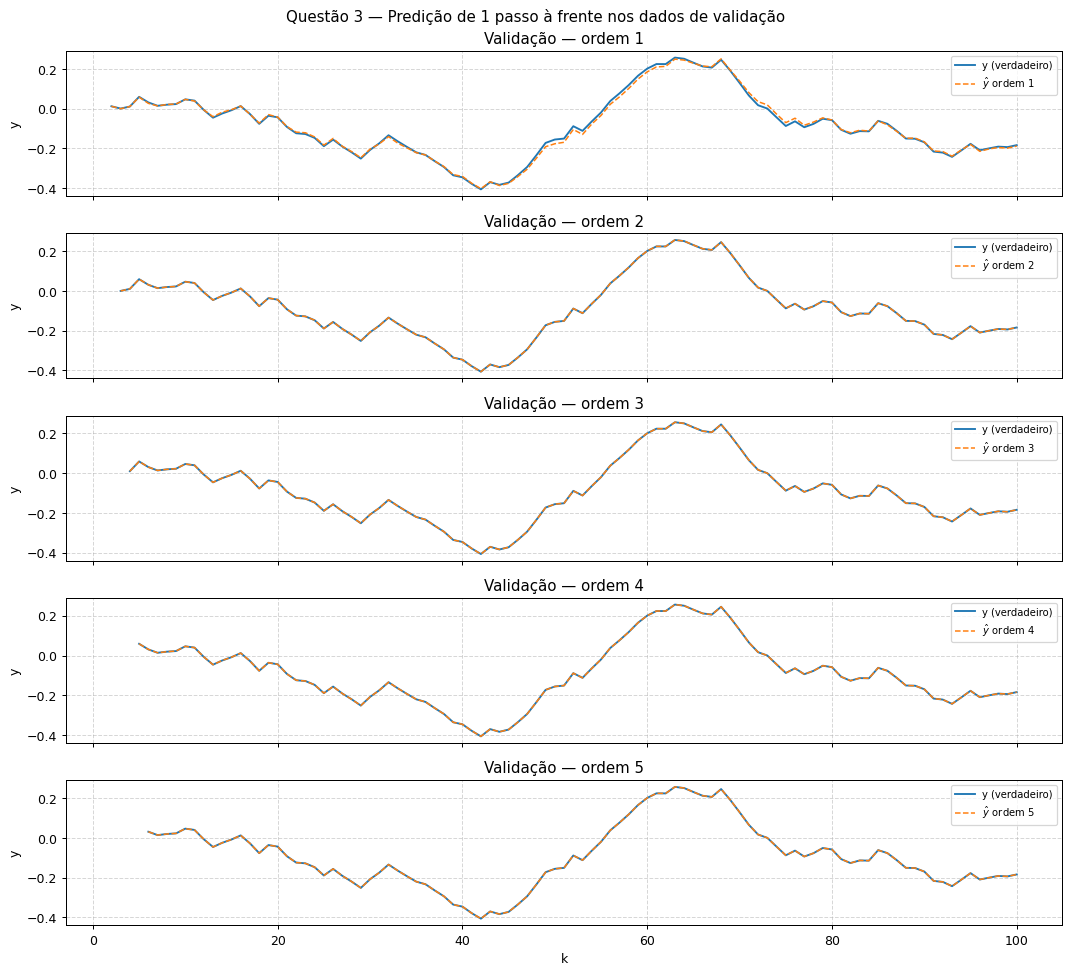

In [ ]:
rng_val = np.random.default_rng(seed=777)
u_val = rng_val.uniform(-1.0, 1.0, size=N)
y_val_true = simulate_diffeq(num_a, den_a, u_val)

print(f"{'ordem':>6}{'SSE':>14}{'MSE':>14}{'R²':>12}{'SNR (dB)':>12}")
linhas = []
for n, theta in thetas_by_order.items():
    y_val_hat = predict_arx(theta, y_val_true, u_val, n)
    m = metrics(y_val_true, y_val_hat, valid_start=n)
    linhas.append((n, m))
    print(f"{n:>6d}{m['SSE']:>14.4e}{m['MSE']:>14.4e}"
          f"{m['R2']:>12.6f}{m['SNR_dB']:>12.2f}")

# Visualização: sobrepõe y_true vs y_hat para cada ordem
fig, axes = plt.subplots(len(thetas_by_order), 1, figsize=(12, 11), sharex=True)
for ax, (n, theta) in zip(axes, thetas_by_order.items()):
    y_hat = predict_arx(theta, y_val_true, u_val, n)
    k = np.arange(1, N + 1)
    ax.plot(k[n:], y_val_true[n:], label="y (verdadeiro)", linewidth=1.5)
    ax.plot(k[n:], y_hat[n:], "--", label=fr"$\hat y$ ordem {n}", linewidth=1.2)
    ax.set_ylabel("y"); ax.grid(True, ls="--", alpha=0.5)
    ax.set_title(f"Validação — ordem {n}"); ax.legend(fontsize=8)
axes[-1].set_xlabel("k")
fig.suptitle("Questão 3 — Predição de 1 passo à frente nos dados de validação")
fig.tight_layout(); plt.show()


**Leitura.** Como na Questão 2 os dados são sem ruído, o modelo de ordem 3 recupera os coeficientes exatos: SSE $\to 0$, $R^2 \to 1$, SNR divergindo. Ordens 1 e 2 têm SSE visível; ordens 4 e 5 também acertam (a estrutura verdadeira é subcaso delas), mas com potencialmente mais variância se houvesse ruído. A validação separada confirma a escolha de ordem 3 feita pelo critério do resíduo.


## Questão 4 — Identificação ARX e ARMAX dos datasets 1 e 2

Para cada conjunto (`dados_1.txt` e `dados_2.txt`):

1. Carregar os pares $(y[k], u[k])$ — primeira coluna $y$, segunda $u$.
2. Dividir em **estimação** (primeiros 70 %) e **validação** (30 % restantes).
3. Ajustar modelos **ARX** e **ARMAX** de ordem 1 a 5 no conjunto de estimação.
4. Calcular o **MSE** em cada conjunto, totalizando uma tabela com $2 \times 5 = 10$ modelos por dataset.
5. Escolher o melhor com base na menor MSE de validação (parcimônia + capacidade de generalizar).


In [ ]:
def load_dataset(path):
    data = np.loadtxt(path)
    return data[:, 0].astype(float), data[:, 1].astype(float)


def split_estim_val(y, u, frac=0.7):
    N = len(y)
    k_cut = int(N * frac)
    return (y[:k_cut], u[:k_cut]), (y[k_cut:], u[k_cut:])


def run_arx_armax(y_e, u_e, y_v, u_v, orders=range(1, 6)):
    """Ajusta ARX e ARMAX para cada ordem e retorna tabelas de MSE."""
    resultados = []
    for n in orders:
        theta_arx, res_arx, y_hat_e_arx = lse_fit_arx(y_e, u_e, n)
        y_hat_v_arx = predict_arx(theta_arx, y_v, u_v, n)
        m_e_arx = metrics(y_e[n:], y_hat_e_arx, 0)
        m_v_arx = metrics(y_v, y_hat_v_arx, valid_start=n)

        theta_arm, res_arm, y_hat_e_arm = armax_fit(y_e, u_e, n)
        y_hat_v_arm = predict_armax(theta_arm, y_v, u_v, n)
        m_e_arm = metrics(y_e[n:], y_hat_e_arm, 0)
        m_v_arm = metrics(y_v, y_hat_v_arm, valid_start=n)

        resultados.append(dict(
            ordem=n,
            theta_arx=theta_arx, theta_armax=theta_arm,
            mse_est_arx=m_e_arx["MSE"], mse_val_arx=m_v_arx["MSE"],
            r2_val_arx=m_v_arx["R2"], snr_val_arx=m_v_arx["SNR_dB"],
            mse_est_armax=m_e_arm["MSE"], mse_val_armax=m_v_arm["MSE"],
            r2_val_armax=m_v_arm["R2"], snr_val_armax=m_v_arm["SNR_dB"],
        ))
    return resultados


def imprime_tabela(nome, resultados):
    print(f"\n=== {nome} ===")
    print(f"{'ordem':>6}{'ARX MSE est':>14}{'ARX MSE val':>14}{'ARX R² val':>12}"
          f"{'ARMAX MSE est':>16}{'ARMAX MSE val':>16}{'ARMAX R² val':>14}")
    for r in resultados:
        print(f"{r['ordem']:>6d}{r['mse_est_arx']:>14.4e}{r['mse_val_arx']:>14.4e}"
              f"{r['r2_val_arx']:>12.4f}"
              f"{r['mse_est_armax']:>16.4e}{r['mse_val_armax']:>16.4e}"
              f"{r['r2_val_armax']:>14.4f}")


def melhor_modelo(resultados):
    """Seleciona (tipo, ordem) pelo menor MSE de validação."""
    candidatos = []
    for r in resultados:
        candidatos.append(("ARX", r["ordem"], r["mse_val_arx"]))
        candidatos.append(("ARMAX", r["ordem"], r["mse_val_armax"]))
    candidatos.sort(key=lambda x: x[2])
    return candidatos[0]



=== dados_1.txt  (N=500, estim=350, valid=150) ===
 ordem   ARX MSE est   ARX MSE val  ARX R² val   ARMAX MSE est   ARMAX MSE val  ARMAX R² val
     1    1.2778e-02    1.1923e-02      0.8508      1.0002e-02      9.1457e-03        0.8856
     2    1.1323e-02    1.0294e-02      0.8720      9.3518e-03      9.1995e-03        0.8856
     3    9.5816e-03    9.1291e-03      0.8870      9.0337e-03      9.8431e-03        0.8782
     4    9.4909e-03    9.0867e-03      0.8871      8.7830e-03      9.0269e-03        0.8879
     5    9.2767e-03    9.2811e-03      0.8853      8.7995e-03      9.0874e-03        0.8877
Melhor modelo para dados_1.txt: ARMAX ordem 4 (MSE_val = 9.0269e-03)


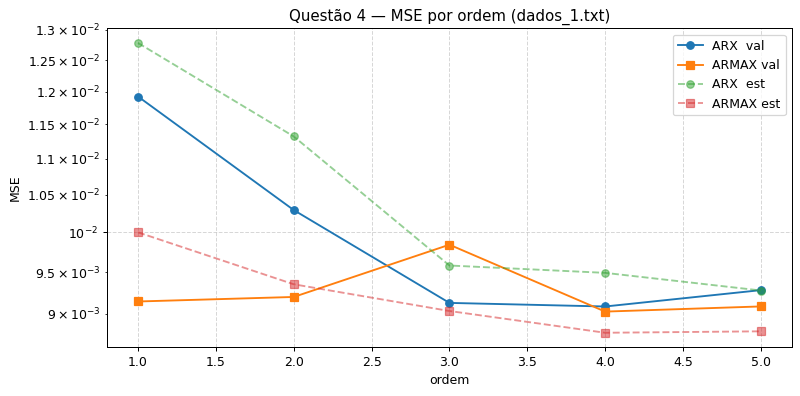


=== dados_2.txt  (N=500, estim=350, valid=150) ===
 ordem   ARX MSE est   ARX MSE val  ARX R² val   ARMAX MSE est   ARMAX MSE val  ARMAX R² val
     1    1.2588e-02    1.2269e-02      0.9167      1.2407e-02      1.2123e-02        0.9177
     2    1.2157e-02    1.1929e-02      0.9184      1.1047e-02      1.0338e-02        0.9293
     3    1.1878e-02    1.1687e-02      0.9199      1.0257e-02      9.8209e-03        0.9327
     4    1.0847e-02    1.0198e-02      0.9294      1.0044e-02      9.8665e-03        0.9317
     5    1.0323e-02    9.9014e-03      0.9305      1.0091e-02      1.3927e-02        0.9022
Melhor modelo para dados_2.txt: ARMAX ordem 3 (MSE_val = 9.8209e-03)


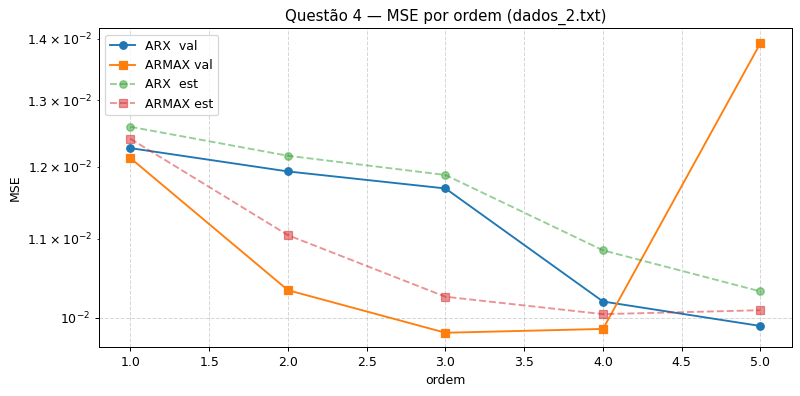

In [ ]:
import os
DATA_DIR = "dataset"
for idx in [1, 2]:
    path = os.path.join(DATA_DIR, f"dados_{idx}.txt")
    y, u = load_dataset(path)
    (y_e, u_e), (y_v, u_v) = split_estim_val(y, u, 0.7)
    resultados = run_arx_armax(y_e, u_e, y_v, u_v)
    imprime_tabela(f"dados_{idx}.txt  (N={len(y)}, estim={len(y_e)}, valid={len(y_v)})",
                   resultados)

    tipo, ordem, mse = melhor_modelo(resultados)
    print(f"Melhor modelo para dados_{idx}.txt: {tipo} ordem {ordem} (MSE_val = {mse:.4e})")

    # Plot MSE vs ordem para ARX e ARMAX
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ordens = [r["ordem"] for r in resultados]
    ax.plot(ordens, [r["mse_val_arx"] for r in resultados], "o-",  label="ARX  val")
    ax.plot(ordens, [r["mse_val_armax"] for r in resultados], "s-", label="ARMAX val")
    ax.plot(ordens, [r["mse_est_arx"] for r in resultados], "o--", alpha=0.5, label="ARX  est")
    ax.plot(ordens, [r["mse_est_armax"] for r in resultados], "s--", alpha=0.5, label="ARMAX est")
    ax.set_xlabel("ordem"); ax.set_ylabel("MSE"); ax.set_yscale("log")
    ax.set_title(f"Questão 4 — MSE por ordem (dados_{idx}.txt)")
    ax.grid(True, ls="--", alpha=0.5); ax.legend()
    fig.tight_layout(); plt.show()


**Critério de escolha.** Preferimos a ordem e a estrutura (ARX ou ARMAX) que **minimizam o MSE de validação**, dando prioridade à parcimônia (menor número de parâmetros) quando as diferenças são pequenas. Um MSE de estimação muito menor que o de validação indica sobreajuste. Se o ARMAX bate o ARX sensivelmente, o resíduo tem estrutura autocorrelacionada que a parte MA capturou.


## Questão 5 — Datasets 3 e 4: modelos variam no tempo?

Mesmo procedimento da Questão 4 (ARX/ARMAX, ordens 1–5, MSE de estimação e validação), **com um passo adicional**: rodamos o **RLS (Recursivo)** de ordem 3 sobre todo o conjunto de dados e plotamos a trajetória dos parâmetros $\theta[k]$ ao longo do tempo. Se as curvas se **estabilizam** após um transitório, o sistema é invariante; se continuam vagando, há variação temporal (non-stationary / time-varying).



=== dados_3.txt  (N=500) ===
 ordem   ARX MSE est   ARX MSE val  ARX R² val   ARMAX MSE est   ARMAX MSE val  ARMAX R² val
     1    4.4965e-02    1.4326e-01      0.4723      4.3785e-02      1.3545e-01        0.5011
     2    2.9382e-02    1.6116e-01      0.4098      2.4012e-02      9.7237e-02        0.6439
     3    2.4294e-02    1.0220e-01      0.6278      2.1026e-02      7.9421e-02        0.7108
     4    1.9267e-02    7.2778e-02      0.7368      1.7754e-02      7.3605e-02        0.7338
     5    1.8773e-02    6.8061e-02      0.7555      1.7620e-02      7.4727e-02        0.7315
Melhor modelo para dados_3.txt: ARX ordem 5 (MSE_val = 6.8061e-02)


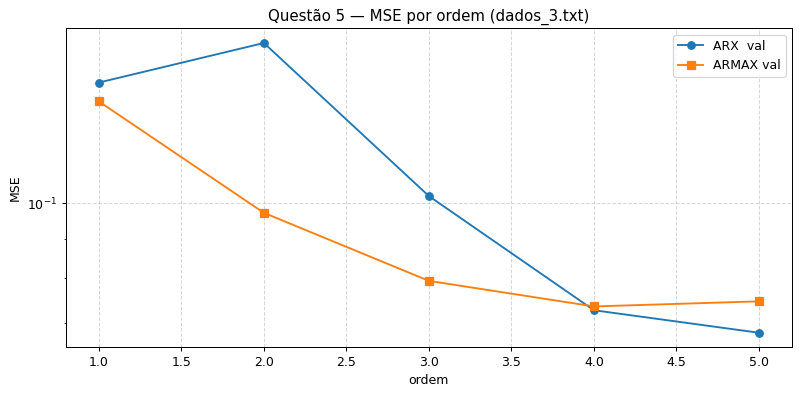

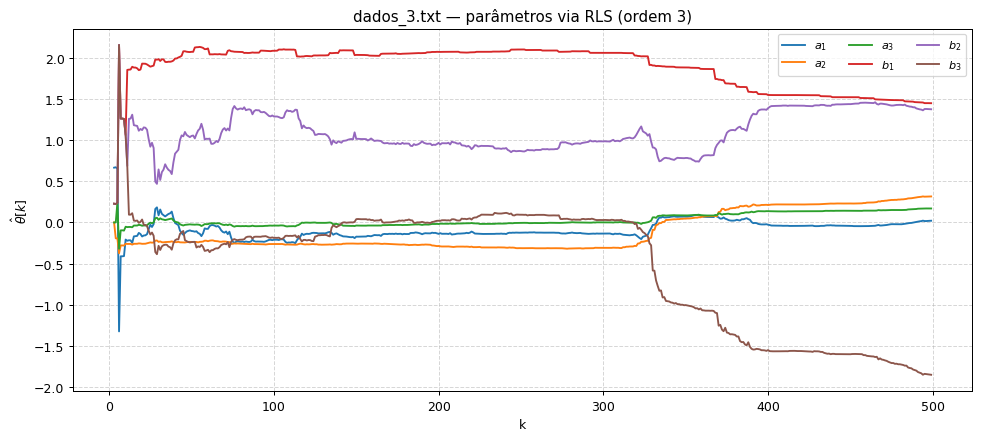

Parâmetros finais RLS (dados_3.txt): [ 0.0212  0.3168  0.1703  1.4521  1.3783 -1.8539]



=== dados_4.txt  (N=500) ===
 ordem   ARX MSE est   ARX MSE val  ARX R² val   ARMAX MSE est   ARMAX MSE val  ARMAX R² val
     1    2.1979e-01    1.7684e-01      0.6780      1.3323e-01      8.9491e-01       -0.6296
     2    1.0963e-02    1.4794e-02      0.9727      9.2167e-03      1.1654e-02        0.9785
     3    9.6013e-03    1.1888e-02      0.9782      9.0778e-03      1.1593e-02        0.9787
     4    9.1790e-03    1.1691e-02      0.9785      9.0292e-03      1.1840e-02        0.9782
     5    9.1987e-03    1.1716e-02      0.9785      9.0558e-03      1.1815e-02        0.9784
Melhor modelo para dados_4.txt: ARMAX ordem 3 (MSE_val = 1.1593e-02)


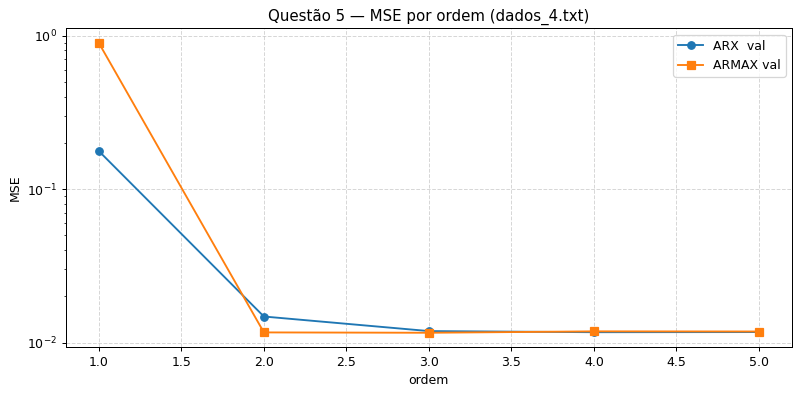

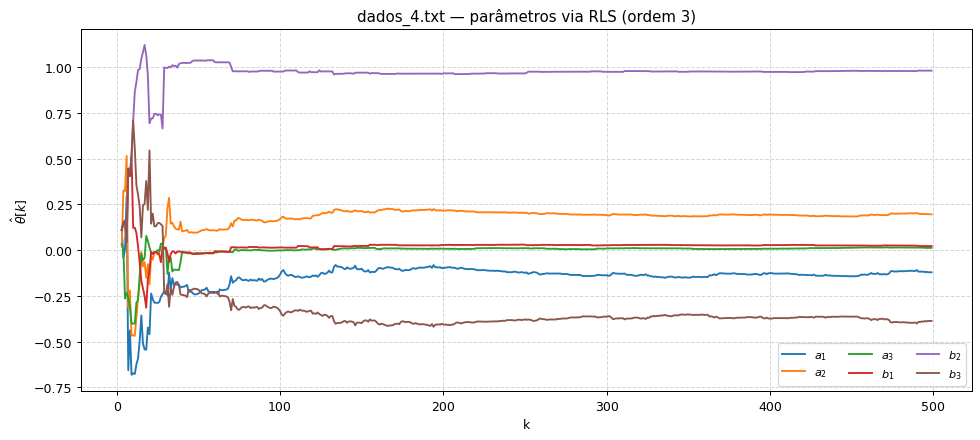

Parâmetros finais RLS (dados_4.txt): [-0.1213  0.1957  0.0123  0.0221  0.9808 -0.3872]


In [ ]:
for idx in [3, 4]:
    path = os.path.join(DATA_DIR, f"dados_{idx}.txt")
    y, u = load_dataset(path)
    (y_e, u_e), (y_v, u_v) = split_estim_val(y, u, 0.7)
    resultados = run_arx_armax(y_e, u_e, y_v, u_v)
    imprime_tabela(f"dados_{idx}.txt  (N={len(y)})", resultados)

    tipo, ordem, mse = melhor_modelo(resultados)
    print(f"Melhor modelo para dados_{idx}.txt: {tipo} ordem {ordem} (MSE_val = {mse:.4e})")

    # MSE vs ordem
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ordens = [r["ordem"] for r in resultados]
    ax.plot(ordens, [r["mse_val_arx"] for r in resultados], "o-",  label="ARX  val")
    ax.plot(ordens, [r["mse_val_armax"] for r in resultados], "s-", label="ARMAX val")
    ax.set_xlabel("ordem"); ax.set_ylabel("MSE"); ax.set_yscale("log")
    ax.set_title(f"Questão 5 — MSE por ordem (dados_{idx}.txt)")
    ax.grid(True, ls="--", alpha=0.5); ax.legend()
    fig.tight_layout(); plt.show()

    # RLS: trajetória dos parâmetros
    n_rls = 3
    theta_f, theta_hist, err = rls_arx(y, u, n_rls, lam=1.0, P0=1000.0)
    k = np.arange(len(y))
    labels_theta = [fr"$a_{i}$" for i in range(1, n_rls + 1)] + \
                   [fr"$b_{j}$" for j in range(1, n_rls + 1)]
    fig, ax = plt.subplots(figsize=(11, 5))
    for j in range(2 * n_rls):
        ax.plot(k[n_rls:], theta_hist[n_rls:, j], label=labels_theta[j])
    ax.set_xlabel("k"); ax.set_ylabel(r"$\hat\theta[k]$")
    ax.set_title(f"dados_{idx}.txt — parâmetros via RLS (ordem {n_rls})")
    ax.grid(True, ls="--", alpha=0.5); ax.legend(ncol=3, fontsize=9)
    fig.tight_layout(); plt.show()
    print(f"Parâmetros finais RLS (dados_{idx}.txt): {theta_f}")


**Como interpretar a trajetória do RLS.**

- Após o transitório inicial (primeiras dezenas de amostras, $P$ grande), se $\theta[k]$ **converge para um valor constante** → sistema é aproximadamente **invariante no tempo**; o EMQ em lote na estimação produz estimativas confiáveis.
- Se $\theta[k]$ continuar variando — deriva lenta, oscilação de baixa frequência, saltos — há **não-estacionariedade**; nesse caso o ideal é usar **fator de esquecimento** $\lambda < 1$ (ex.: $0{,}95$–$0{,}99$) para dar mais peso aos dados recentes.
- A escolha do melhor modelo na tabela deve ser lida em conjunto: se o MSE de validação é alto e $\theta[k]$ diverge, a estrutura fixa ARX/ARMAX pode ser insuficiente.


## Questão 6 — Datasets 5 e 6: AIC/BIC + RELS

Dois passos combinados:

1. **Seleção de estrutura** via critérios de informação, que penalizam o número de parâmetros $p$:
    - **Akaike (AIC):** $\mathrm{AIC}(p) = N \ln\!\left(\dfrac{\mathrm{SSE}}{N}\right) + 2p$.
    - **Bayes (BIC):** $\mathrm{BIC}(p) = N \ln\!\left(\dfrac{\mathrm{SSE}}{N}\right) + p \ln(N)$.
    BIC penaliza mais $p$ para $N$ grande, tendendo a preferir modelos mais parcimoniosos.
2. **Identificação recursiva** via **RELS** (Recursive Extended Least Squares) para modelos ARMAX — estende o RLS incluindo no regressor as estimativas passadas do ruído.

Para cada dataset: varremos ordens 1–5 para ARX e ARMAX, computamos AIC/BIC sobre todo o conjunto, escolhemos a ordem que minimiza cada critério e rodamos o RELS para visualizar a convergência dos parâmetros da estrutura escolhida.



=== dados_5.txt  (N=1000) ===
 ordem       SSE ARX     AIC ARX     BIC ARX     SSE ARMAX   AIC ARMAX   BIC ARMAX
     1     2.289e+02    -1467.98    -1458.16     2.053e+02    -1574.86    -1560.14
     2     2.055e+02    -1569.21    -1549.59     1.801e+02    -1696.77    -1667.34
     3     1.804e+02    -1692.39    -1662.96     1.761e+02    -1710.25    -1666.11
     4     1.791e+02    -1692.94    -1653.71     1.715e+02    -1728.20    -1669.35
     5     1.745e+02    -1712.05    -1663.02     1.700e+02    -1727.94    -1654.40
  Mínimo AIC: ('ARMAX', 4, np.float64(-1728.198797612217))
  Mínimo BIC: ('ARMAX', 4, np.float64(-1669.3538305212019))


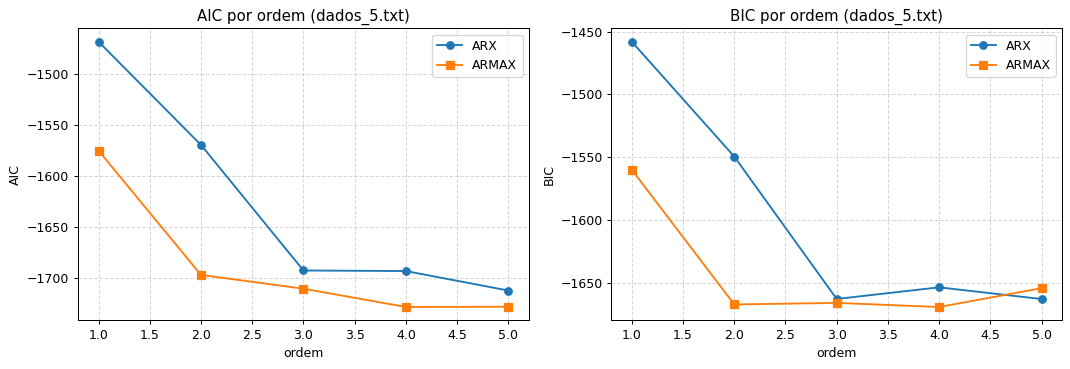

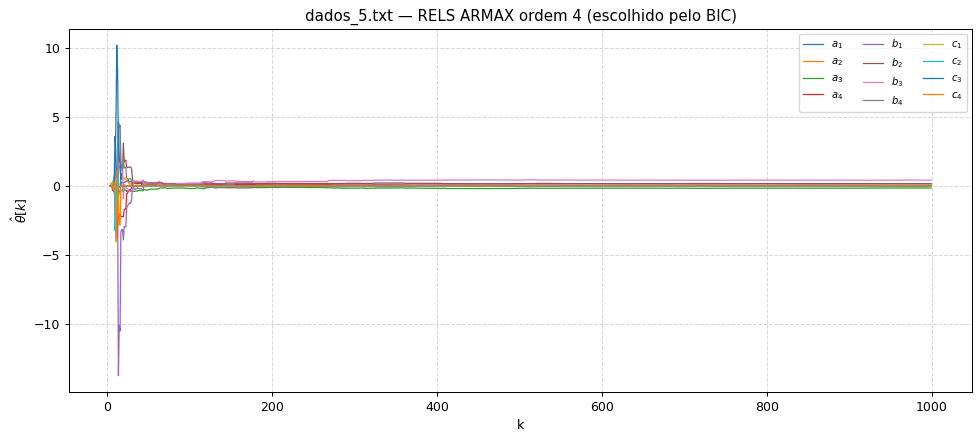

Parâmetros finais RELS: [-0.0001 -0.0541 -0.1565  0.0285  0.1578  0.1482  0.4131 -0.0048 -0.0006
 -0.0009  0.0018 -0.001 ]

=== dados_6.txt  (N=500) ===
 ordem       SSE ARX     AIC ARX     BIC ARX     SSE ARMAX   AIC ARMAX   BIC ARMAX
     1     9.088e+01     -845.81     -837.39     8.309e+01     -888.57     -875.93
     2     7.188e+01     -955.96     -939.12     5.057e+01    -1127.10    -1101.83
     3     4.417e+01    -1191.04    -1165.79     4.221e+01    -1207.62    -1169.74
     4     4.250e+01    -1202.71    -1169.06     3.990e+01    -1226.04    -1175.56
     5     4.155e+01    -1206.42    -1164.37     3.969e+01    -1219.17    -1156.11
  Mínimo AIC: ('ARMAX', 4, np.float64(-1226.0403532016833))
  Mínimo BIC: ('ARMAX', 4, np.float64(-1175.561442080984))


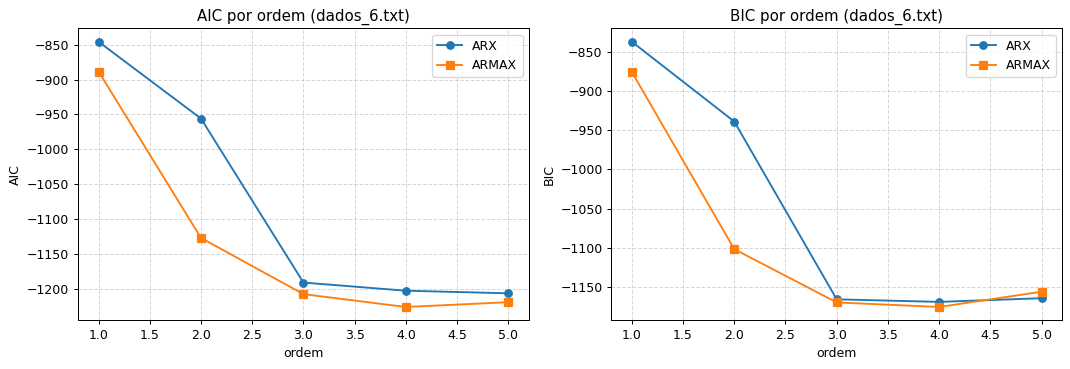

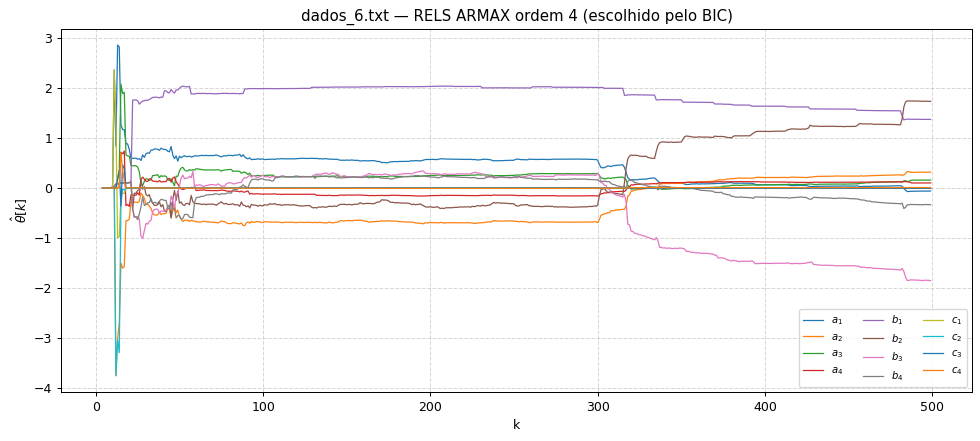

Parâmetros finais RELS: [-0.0581  0.3182  0.1602  0.103   1.3712  1.7319 -1.8481 -0.3311  0.0024
 -0.0053 -0.0056  0.0109]


In [ ]:
def varredura_aic_bic(y, u, orders=range(1, 6)):
    """Para cada ordem e cada estrutura, ajusta no conjunto completo e
    calcula SSE, AIC, BIC."""
    linhas = []
    for n in orders:
        # ARX
        theta_arx, res_arx, _ = lse_fit_arx(y, u, n)
        p_arx = 2 * n
        sse_arx = float(np.sum(res_arx ** 2))
        cri_arx = aic_bic(sse_arx, len(res_arx), p_arx)
        # ARMAX
        theta_arm, res_arm, _ = armax_fit(y, u, n)
        p_arm = 3 * n
        sse_arm = float(np.sum(res_arm ** 2))
        cri_arm = aic_bic(sse_arm, len(res_arm), p_arm)
        linhas.append(dict(
            ordem=n,
            sse_arx=sse_arx, aic_arx=cri_arx["AIC"], bic_arx=cri_arx["BIC"],
            sse_armax=sse_arm, aic_armax=cri_arm["AIC"], bic_armax=cri_arm["BIC"],
            theta_arx=theta_arx, theta_armax=theta_arm,
        ))
    return linhas


for idx in [5, 6]:
    path = os.path.join(DATA_DIR, f"dados_{idx}.txt")
    y, u = load_dataset(path)
    linhas = varredura_aic_bic(y, u)
    print(f"\n=== dados_{idx}.txt  (N={len(y)}) ===")
    print(f"{'ordem':>6}{'SSE ARX':>14}{'AIC ARX':>12}{'BIC ARX':>12}"
          f"{'SSE ARMAX':>14}{'AIC ARMAX':>12}{'BIC ARMAX':>12}")
    for r in linhas:
        print(f"{r['ordem']:>6d}{r['sse_arx']:>14.3e}{r['aic_arx']:>12.2f}"
              f"{r['bic_arx']:>12.2f}"
              f"{r['sse_armax']:>14.3e}{r['aic_armax']:>12.2f}{r['bic_armax']:>12.2f}")

    # Melhor por cada critério
    best_aic = min(
        [("ARX",   r["ordem"], r["aic_arx"])   for r in linhas] +
        [("ARMAX", r["ordem"], r["aic_armax"]) for r in linhas],
        key=lambda t: t[2])
    best_bic = min(
        [("ARX",   r["ordem"], r["bic_arx"])   for r in linhas] +
        [("ARMAX", r["ordem"], r["bic_armax"]) for r in linhas],
        key=lambda t: t[2])
    print(f"  Mínimo AIC: {best_aic}")
    print(f"  Mínimo BIC: {best_bic}")

    # Plot AIC/BIC
    ordens = [r["ordem"] for r in linhas]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    ax[0].plot(ordens, [r["aic_arx"]   for r in linhas], "o-", label="ARX")
    ax[0].plot(ordens, [r["aic_armax"] for r in linhas], "s-", label="ARMAX")
    ax[0].set_title(f"AIC por ordem (dados_{idx}.txt)")
    ax[0].set_xlabel("ordem"); ax[0].set_ylabel("AIC"); ax[0].grid(True, ls="--", alpha=0.5); ax[0].legend()
    ax[1].plot(ordens, [r["bic_arx"]   for r in linhas], "o-", label="ARX")
    ax[1].plot(ordens, [r["bic_armax"] for r in linhas], "s-", label="ARMAX")
    ax[1].set_title(f"BIC por ordem (dados_{idx}.txt)")
    ax[1].set_xlabel("ordem"); ax[1].set_ylabel("BIC"); ax[1].grid(True, ls="--", alpha=0.5); ax[1].legend()
    fig.tight_layout(); plt.show()

    # RELS na ordem selecionada pelo BIC (mais parcimonioso)
    _, ord_bic, _ = best_bic
    theta_f, theta_hist, e_hat = rels_armax(y, u, ord_bic, lam=1.0, P0=1000.0)
    k = np.arange(len(y))
    fig, ax = plt.subplots(figsize=(11, 5))
    labels_theta = (
        [fr"$a_{i}$" for i in range(1, ord_bic + 1)]
        + [fr"$b_{j}$" for j in range(1, ord_bic + 1)]
        + [fr"$c_{m}$" for m in range(1, ord_bic + 1)]
    )
    for j in range(3 * ord_bic):
        ax.plot(k[ord_bic:], theta_hist[ord_bic:, j], label=labels_theta[j], linewidth=1)
    ax.set_xlabel("k"); ax.set_ylabel(r"$\hat\theta[k]$")
    ax.set_title(f"dados_{idx}.txt — RELS ARMAX ordem {ord_bic} (escolhido pelo BIC)")
    ax.grid(True, ls="--", alpha=0.5); ax.legend(ncol=3, fontsize=8)
    fig.tight_layout(); plt.show()
    print(f"Parâmetros finais RELS: {theta_f}")


**Leitura dos critérios.**

- **AIC** tende a super-estimar a ordem em amostras grandes; é útil para priorizar ajuste.
- **BIC** penaliza mais severamente parâmetros adicionais para $N$ grande — mais conservador, costuma ser preferido quando a amostra é grande (caso do `dados_5.txt` com 1000 pontos).
- Quando AIC e BIC apontam para **ordens diferentes**, o veredito preferencial é o BIC, por consistência assintótica: se o modelo verdadeiro está na família testada, $P(\text{BIC escolhe a ordem certa}) \to 1$ quando $N \to \infty$.

**RELS.** A trajetória dos coeficientes $\hat a_i, \hat b_j, \hat c_m$ sob RELS mostra: (i) a convergência a partir de $\theta_0 = 0$ e $P_0 = 10^3 I$, (ii) se o sistema é estacionário (curvas que estabilizam) e (iii) onde eventuais mudanças estruturais ocorrem (saltos ou deriva).

---

## Referência rápida — funções do notebook

| Função | Papel |
|--------|-------|
| `simulate_diffeq(num, den, u)` | Simula a saída por equação a diferença. |
| `lse_fit_arx(y, u, n)` | EMQ ARX; retorna $\theta$, resíduo e $\hat y$. |
| `armax_fit(y, u, n)` | EMQE iterativo para ARMAX. |
| `predict_arx` / `predict_armax` | Predição 1-passo em dados novos. |
| `rls_arx`, `rels_armax` | Versões recursivas (com histórico de $\theta[k]$). |
| `metrics(y, y_hat)` | SSE, MSE, $R^2$, SNR (dB). |
| `aic_bic(sse, N, p)` | Critérios de informação de Akaike e Bayes. |
